In [1]:
import gzip 

import Bio
import Bio.SeqIO

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
datadir = "data/jared_PacBio_data_2"

In [3]:
binfile = datadir + "/bin1.fastq.gz"

In [4]:
WT_fasta = Bio.SeqIO.read(datadir + "/2D.fasta", format="fasta")

WT_DNA = WT_fasta.seq
WT_DNA

Seq('ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCA...TGA')

In [5]:
WT = WT_DNA.translate()

In [6]:
with gzip.open(binfile, "rt") as fh:
    records = list(Bio.SeqIO.parse(fh, "fastq"))

In [7]:
start = 53
end = 875

length_cutoff = 1
min_phred_base = 93
mut_cut = 10

In [8]:
len(records)

138204

In [9]:
records_after_length_filter = [r for r in records if len(r) >= length_cutoff*(end)]

In [10]:
len(records_after_length_filter)

124996

In [11]:
records_after_quality_filter = [r for r in records_after_length_filter if 
    min(r.letter_annotations["phred_quality"][start:end], default=-1) >= min_phred_base ]

In [12]:
len(records_after_quality_filter)

55686

In [13]:
def hamming_dist(s1, s2):
    assert(len(s1) == len(s2))
    return sum(1 for (a, b) in zip(s1, s2) if a != b)

In [14]:
def complement_and_translate(r):
    sel = r[start:end].seq
    sel_r = r.reverse_complement()[start:end].seq
    dist = hamming_dist(sel, WT_DNA)
    dist_r = hamming_dist(sel_r, WT_DNA)
    ret = None
    if dist_r > dist:
        ret = sel.translate()
    else:
        ret = sel_r.translate()
    return ret

In [15]:
records_after_translate = [complement_and_translate(r) for r in records_after_quality_filter]

In [16]:
len(records_after_translate)

55686

In [17]:
records_after_mut_filter = [s for s in records_after_translate if hamming_dist(s, WT) < mut_cut]

In [18]:
len(records_after_mut_filter)

48954

In [19]:
final_seqs = [str(s) for s in records_after_mut_filter]

In [20]:
df = pd.DataFrame(final_seqs, columns=["sequence"])

In [21]:
seq_counts = df.value_counts().reset_index()

In [22]:
seq_counts.columns = ["sequence", "value_count"]

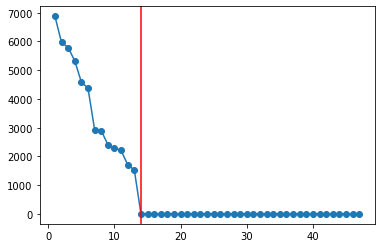

In [23]:
plt.plot(np.arange(1, len(seq_counts) + 1), seq_counts.value_count, 'o-')
plt.axvline(14, color="red")

In [24]:
seq_counts

,sequence,value_count
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,6877
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5964
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5789
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADKADAIVMDIVPDG...,5322
4,MQHTYPAQLMRFATAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4587
5,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4375
6,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2931
7,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2897
8,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2413
9,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2291
